<a href="https://colab.research.google.com/github/informloulie/music-computing/blob/main/assignments/labAssignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display

In [2]:
def plotAudio2(sig,sampleRate,title):

    # from Assignment 2/Google Doc

    # this version expects the audio file to have already been opened by librosa
    plt.figure(figsize=(15, 5)) # Create a new figure
    librosa.display.waveshow(sig, sr=sampleRate) # Plot the waveform
    plt.title(title) # Set the title
    plt.xlabel("Time") # Add x-axis label
    plt.ylabel("Amplitude") # Add y-axis label
    plt.show() # Display the plot


In [12]:
def plotAudioFreqDomain(sig, samplingRate):
    # create a normalized spectrogram
    # this includes several function calls
    # first create a basic spectrogram with librosa.stft() with the default window size (2048)
    # then make all of values in the spectrogram positive with np.abs()
    # then scale the spectrogram to be in decibels, so it better reflects how we hear librosa.amplitude_to_db()
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
    # display the normalized spectrogram with a log frequency scale
    librosa.display.specshow(spec, sr=samplingRate, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Linear-frequency power spectrogram')
    plt.show()

In [28]:
def additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent):

   # from additiveSynthesis.ipynb
       # generate list of harmonics
    harmonics = np.arange(1,numHarmonics+1,seqHarm)
    harmonics = harmonics[1:-1]

    # create a time series from 0 to 1 the inputted length
    timeSeries = np.linspace(0, 1, samplingRate)

    # create a cosine wave for the fundamental
    signal = np.cos(2.0 * np.pi * frequency * timeSeries)

    # add harmonics based on the those specified in the variable 'harmonics'
    for harm in harmonics:
        signal = signal + np.cos(2.0 * np.pi * frequency * harm * timeSeries)/harm**ampExponent

    # scale the signal to between -1 and 1
    excursion=max(abs(signal))
    signal = signal / excursion

    # plot signal
    plt.plot(timeSeries,signal)
    plt.xlabel('Time (Sec)')
    plt.ylabel('Amplitude')
    plt.title('Additive Synthesis')
    plt.plot
    return signal

In [9]:
def makeWaveforms(frequency,samplingRate,numHarmonics,waveType):
    # use an if/elif/else statement to set up the parameters for

    # Initialize with default values for sine wave if no match
    lowestHarm = 1
    seqHarm = 1
    ampExponent = 1

    if waveType == 'sawtooth':
        lowestHarm = 1
        seqHarm = 1
        ampExponent = 1
    elif waveType == 'square':
        lowestHarm = 1
        seqHarm = 2
        ampExponent = 1
    elif waveType == 'triangle':
        lowestHarm = 1
        seqHarm = 2
        ampExponent = 2
    # the different type of waveforms based on the code in
    # additiveSynthesis.ipynb
    # if, elif (else if) and else can be used to evaluate the contents of a variable

    # call additiveSynthesis() to generate a waveform
    signal = additiveSynthesis(samplingRate, frequency, numHarmonics, seqHarm, ampExponent)
    # return the generated waveform (signal)
    return signal

In [25]:
def visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType):
  # call makeWaveforms()
  signal = makeWaveforms(frequency, samplingRate, numHarmonics, waveType)

  # call plotAudio2()
  plotAudio2(signal, samplingRate, f'{waveType.capitalize()} Wave - Time Domain')

  # call plotAudioFreqDomain()
  plotAudioFreqDomain(signal, samplingRate)

  # return the output of makeWaveforms()
  return signal

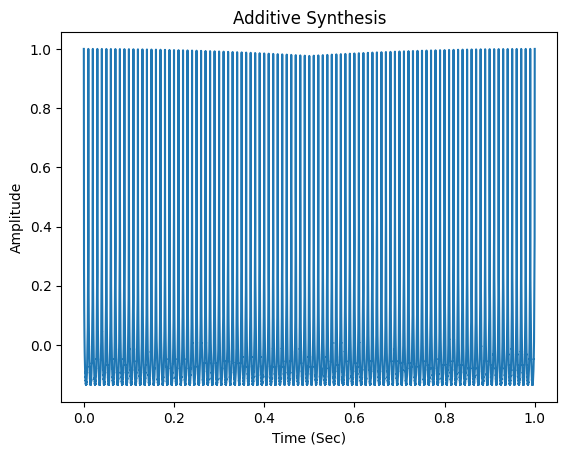

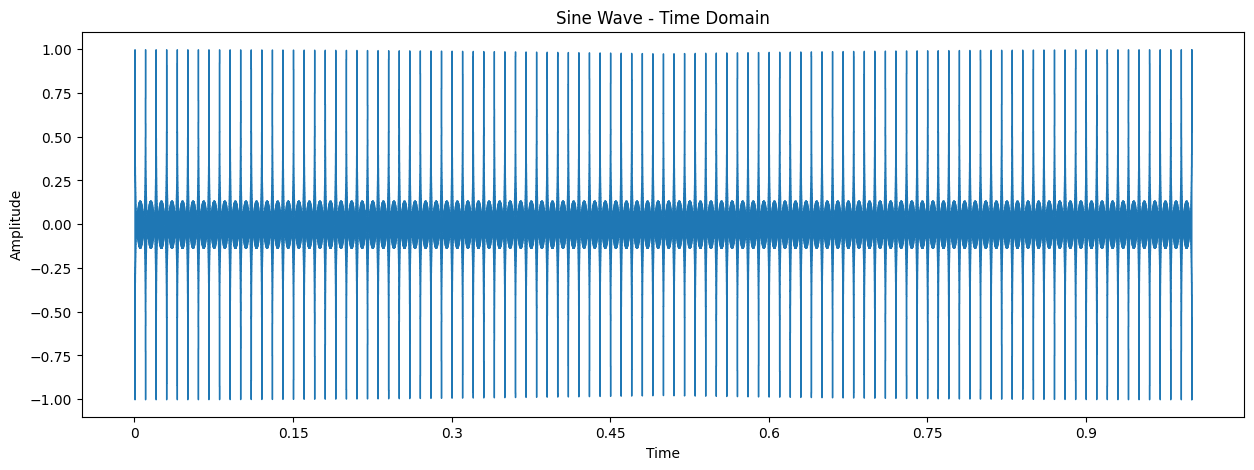

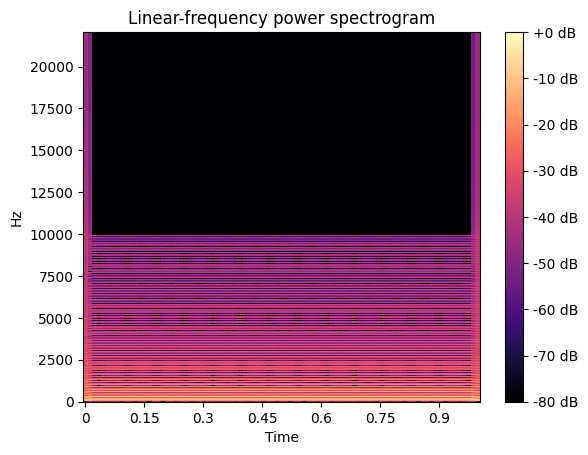

In [29]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sine'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType)
IPython.display.Audio(signal, rate=samplingRate)

In [19]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sawtooth'
winSize = 1024
specType = 'log'

#visualizeWaveforms()
#IPython.display.Audio()

In [20]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'triangle'
winSize = 1024
specType = 'log'

#visualizeWaveforms()
#IPython.display.Audio()

In [21]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'square'
winSize = 1024
specType = 'log'

#visualizeWaveforms()
#IPython.display.Audio()